In [ ]:
# https://www.kaggle.com/datasets/pythonafroz/solar-panel-images?resource=download

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [3]:
DATASET_DIR = r"C:\Users\ADMIN\Solar Panel Classification\data"
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="training",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="validation",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.
Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [4]:
class_names = train_dataset.class_names
num_classes = len(class_names)

In [5]:
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [6]:
num_classes

# Base Model (CNN2D)

# Create model
model = tf.keras.models.Sequential()

# Input layer
model.add(tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# Normalize pixel values (0-255 -> 0-1)
model.add(tf.keras.layers.Rescaling(1.0 / 255))

# Convolution Layer 1
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2, 2)))

# Convolution Layer 2
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2, 2)))

# Convolution Layer 3
model.add(tf.keras.layers.Conv2D(128, (3, 3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2, 2)))

# Flatten layer
model.add(tf.keras.layers.Flatten())

# Fully Connected Layer
model.add(tf.keras.layers.Dense(128, activation="relu"))

# Output layer
model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
# Show model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
EPOCHS = 10

In [10]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 460ms/step - accuracy: 0.2684 - loss: 2.1645 - val_accuracy: 0.4124 - val_loss: 1.5683
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 484ms/step - accuracy: 0.3842 - loss: 1.5328 - val_accuracy: 0.4294 - val_loss: 1.4353
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 486ms/step - accuracy: 0.4986 - loss: 1.3026 - val_accuracy: 0.4181 - val_loss: 1.3557
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 553ms/step - accuracy: 0.5904 - loss: 1.1421 - val_accuracy: 0.5650 - val_loss: 1.1708
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 541ms/step - accuracy: 0.6949 - loss: 0.8974 - val_accuracy: 0.5763 - val_loss: 1.0838
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 541ms/step - accuracy: 0.7698 - loss: 0.6787 - val_accuracy: 0.5876 - val_loss: 1.1625
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 545ms/step - accuracy: 0.8418 - loss: 0.4371 - val_accuracy: 0.6441 - val_loss: 1.2527
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 547ms/step - accuracy: 0.9237 - loss: 0.2379 - val_accu

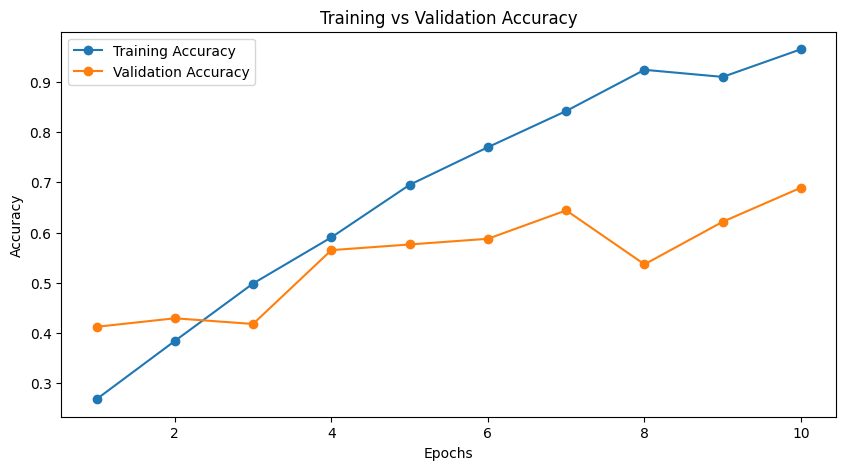

In [11]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, EPOCHS + 1)

plt.figure(figsize= (10,5))
plt.plot(epochs, train_accuracy, label = 'Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label = 'Validation Accuracy', marker = 'o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [12]:
EPOCHS = 20

In [13]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 553ms/step - accuracy: 0.9901 - loss: 0.0508 - val_accuracy: 0.6610 - val_loss: 1.6889
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 544ms/step - accuracy: 0.9915 - loss: 0.0544 - val_accuracy: 0.6045 - val_loss: 1.6236
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 553ms/step - accuracy: 0.9929 - loss: 0.0445 - val_accuracy: 0.6271 - val_loss: 1.7469
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 557ms/step - accuracy: 0.9972 - loss: 0.0368 - val_accuracy: 0.6723 - val_loss: 1.5299
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 563ms/step - accuracy: 0.9958 - loss: 0.0307 - val_accuracy: 0.6723 - val_loss: 1.6463
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 560ms/step - accuracy: 0.9972 - loss: 0.0306 - val_accuracy: 0.6667 - val_loss: 1.5712
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 555ms/step - accuracy: 0.9944 - loss: 0.0270 - val_accuracy: 0.6836 - val_loss: 1.4712
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 596ms/step - accuracy: 0.9944 - loss: 0.0205 - val_accu

In [14]:
# Solve the Overfitting problem

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=3)

from tensorflow.keras.callbacks import LearningRateScheduler

def scheduler(epoch,lr):
  if epoch > 5:
    return lr*0.1
  return lr

lr_schedule = LearningRateScheduler(scheduler)
     

In [15]:
import tensorflow as tf

model = tf.keras.models.Sequential()

# Input layer
model.add(tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# Normalize pixel values
model.add(tf.keras.layers.Rescaling(1.0 / 255))

# Convolution layer: 1
model.add(tf.keras.layers.Conv2D(32, (3,3), activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

# Convolution layer: 2
model.add(tf.keras.layers.Conv2D(64, (3,3), activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

# Convolution layer: 3
model.add(tf.keras.layers.Conv2D(128, (3,3), activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

# Flattening
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.5))

# Fully Connected Layer
model.add(tf.keras.layers.Dense(128, activation="relu"))

# Output layer
model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

In [16]:
# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
# Show summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 52, 52, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,170,630 (42.61 MB)

 Trainable params: 11,170,182 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
EPOCHS = 10

In [19]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.3573 - loss: 23.7290 - val_accuracy: 0.1130 - val_loss: 77.8185
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.4831 - loss: 1.7383 - val_accuracy: 0.1130 - val_loss: 67.6769
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.5282 - loss: 1.2151 - val_accuracy: 0.1073 - val_loss: 31.5219
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.6102 - loss: 1.0243 - val_accuracy: 0.2373 - val_loss: 13.6785
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.6667 - loss: 0.8369 - val_accuracy: 0.2429 - val_loss: 13.0848
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7472 - loss: 0.7054 - val_accuracy: 0.2429 - val_loss: 13.8005
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.7782 - loss: 0.6358 - val_accuracy: 0.2599 - val_loss: 13.3054
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.7613 - loss: 0.6795 - val_accuracy: 0.2429 - v

In [20]:
import tensorflow as tf
from tensorflow.keras.layers import (
    RandomFlip, RandomRotation, RandomZoom,
    Rescaling, Conv2D, BatchNormalization, MaxPooling2D,
    Flatten, Dropout, Dense, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2


data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.15),
    RandomZoom(0.15),
    # Optional: add RandomContrast(0.2) if colors vary a lot
])

In [21]:
# Grok.com's recommendation

import tensorflow as tf
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# -------------------------------
# Data Augmentation
# -------------------------------
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

# -------------------------------
# Build the Model
# -------------------------------
model = tf.keras.models.Sequential()

# Input layer
model.add(tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# Data Augmentation
model.add(data_augmentation)

# Normalize pixel values
model.add(tf.keras.layers.Rescaling(1.0 / 255))

# Conv Block 1
model.add(Conv2D(32, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Conv Block 2
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Conv Block 3
model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.35))

# Classifier
model.add(Flatten())

# Dense Layers
model.add(Dense(256, activation="relu", kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(128, activation="relu", kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output layer
model.add(Dense(num_classes, activation="softmax"))

# -------------------------------
# Compile
# -------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -------------------------------
# Callbacks
# -------------------------------
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

# -------------------------------
# Train
# -------------------------------
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

# -------------------------------
# Final Results
# -------------------------------
print("\nTraining complete!")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.3263 - loss: 2.8988 - val_accuracy: 0.2429 - val_loss: 4.4180 - learning_rate: 3.0000e-04
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.4308 - loss: 2.5741 - val_accuracy: 0.2429 - val_loss: 8.8182 - learning_rate: 3.0000e-04
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.4407 - loss: 2.6753 - val_accuracy: 0.2429 - val_loss: 11.5693 - learning_rate: 3.0000e-04
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4656 - loss: 2.5066
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
23/23 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.4463 - loss: 2.5886 - val_accuracy: 0.2429 - val_loss: 8.1936 - learning_rate: 3.0000e-04
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.4788 - loss: 2.4784 - val_accuracy: 0.1130 - val_loss: 6.5706 - learning_rate: 1.5000e-04
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.4831 - loss: 2.35

In [22]:
# Insights so far

# Transfer Learning - MobileNetV2

In [23]:
#MobileNetV2 base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(224,224,3)))
model.add(data_augmentation)
model.add(tf.keras.layers.Rescaling(1.0/255))

model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
   

In [25]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_3 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 601ms/step - accuracy: 0.5268 - loss: 1.2611 - val_accuracy: 0.5819 - val_loss: 1.1265
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 571ms/step - accuracy: 0.7203 - loss: 0.8314 - val_accuracy: 0.6271 - val_loss: 0.9690
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 588ms/step - accuracy: 0.7853 - loss: 0.6246 - val_accuracy: 0.6554 - val_loss: 1.0218
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 565ms/step - accuracy: 0.8023 - loss: 0.5743 - val_accuracy: 0.7288 - val_loss: 0.7654
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 561ms/step - accuracy: 0.8206 - loss: 0.5199 - val_accuracy: 0.6328 - val_loss: 1.0056
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 570ms/step - accuracy: 0.8347 - loss: 0.4768 - val_accuracy: 0.6836 - val_loss: 0.9243
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 567ms/step - accuracy: 0.8545 - loss: 0.4023 - val_accuracy: 0.7288 - val_loss: 0.7978
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 585ms/step - accuracy: 0.8672 - loss: 0.3798 - val_accu

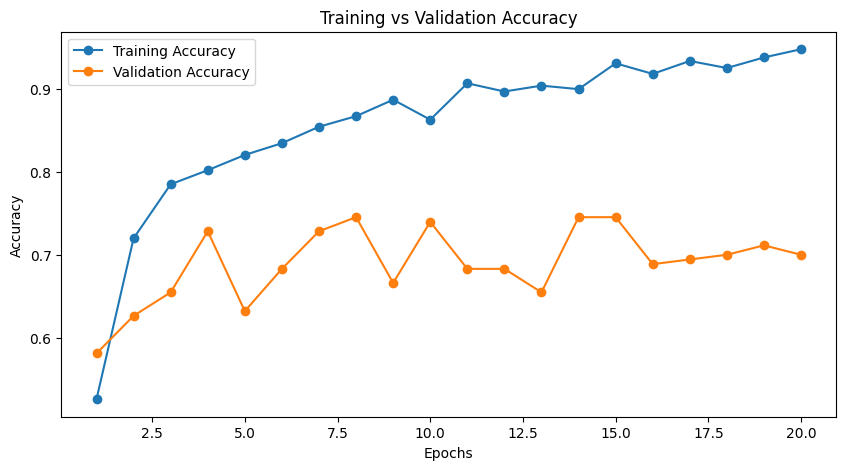

In [27]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, 21)

plt.figure(figsize= (10,5))
plt.plot(epochs, train_accuracy, label = 'Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label = 'Validation Accuracy', marker = 'o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [28]:
model.save("../model/mobilenetv2_2.h5")

In [29]:
# EfficientNet

In [30]:
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="training",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="validation",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.
Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [31]:
class_names = train_dataset.class_names

In [32]:
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [33]:
num_classes = len(class_names)

In [34]:
num_classes

6

In [35]:
class_counts = {}
total_images = 0

for class_name in class_names:
  class_path = os.path.join(DATASET_DIR, class_name)
  count = len(os.listdir(class_path))
  class_counts[class_name] = count
  total_images += count

In [36]:
class_weights = {}

for index, class_name in enumerate(class_names):
  class_weights[index] = total_images / (num_classes * class_counts[class_name])

print("Class weights", class_weights)

Class weights {0: 0.7564766839378239, 1: 0.7525773195876289, 2: 0.7643979057591623, 3: 1.4038461538461537, 4: 2.085714285714286, 5: 1.1774193548387097}


In [37]:
data_augmentation = tf.keras.Sequential()
data_augmentation.add(tf.keras.layers.RandomFlip("horizontal"))
data_augmentation.add(tf.keras.layers.RandomRotation(0.1))
data_augmentation.add(tf.keras.layers.RandomZoom(0.1))

In [38]:
train_images = []
train_labels = []

In [39]:
for images, labels in train_dataset:
  images = preprocess_input(images)
  train_images.append(images)
  train_labels.append(labels)

In [40]:
train_images = tf.concat(train_images, axis=0)
train_labels = tf.concat(train_labels, axis=0)

In [41]:
validation_images = []
validation_labels = []

In [42]:
for images, labels in validation_dataset:
  images = preprocess_input(images)
  validation_images.append(images)
  validation_labels.append(labels)

In [43]:
validation_images = tf.concat(validation_images, axis=0)
validation_labels = tf.concat(validation_labels, axis=0)

In [44]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape = (224,224,3),
    include_top = False,
    weights="imagenet"
)

In [45]:
base_model.trainable = False

In [46]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(224,224,3)))
model.add(data_augmentation)

model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

In [47]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [49]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 15
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 26s 766ms/step - accuracy: 0.5466 - loss: 1.2301 - val_accuracy: 0.6215 - val_loss: 0.9514
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 729ms/step - accuracy: 0.7458 - loss: 0.7264 - val_accuracy: 0.7062 - val_loss: 0.7899
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 715ms/step - accuracy: 0.8023 - loss: 0.5807 - val_accuracy: 0.7062 - val_loss: 0.6846
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 698ms/step - accuracy: 0.8531 - loss: 0.4787 - val_accuracy: 0.7401 - val_loss: 0.6770
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 694ms/step - accuracy: 0.8489 - loss: 0.4511 - val_accuracy: 0.7401 - val_loss: 0.6978
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 708ms/step - accuracy: 0.8842 - loss: 0.3625 - val_accuracy: 0.7345 - val_loss: 0.6718
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 695ms/step - accuracy: 0.8997 - loss: 0.3246 - val_accuracy: 0.7740 - val_loss: 0.6064
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 687ms/step - accuracy: 0.8898 - loss: 0.3210 - val_accu

In [50]:
# Hyper Parameter Optimizationm

!pip install keras-tuner 

import keras_tuner as kt
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Reuse your train_dataset and validation_dataset (with preprocess_input already applied)
# Make sure they are defined as in your original code

def build_model(hp):
    base_model = EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    model = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(hp.Float("rotation_factor", min_value=0.05, max_value=0.3, step=0.05)),
        RandomZoom(hp.Float("zoom_factor", min_value=0.05, max_value=0.3, step=0.05)),
        base_model,
        GlobalAveragePooling2D(),
        Dropout(hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)),
        Dense(
            hp.Int("dense_units", min_value=64, max_value=512, step=64),
            activation='relu'
        ),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Setup Random Search Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,          # Same as n_iter before
    executions_per_trial=1,
    directory='kt_dir',
    project_name='efficientnet_tune',
    overwrite=True
)

# Optional: Early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Run the search
tuner.search(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stopping],
    class_weight=class_weights  # Handles imbalance
)

# Results
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(best_hps.values)

best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate on validation
val_loss, val_acc = best_model.evaluate(validation_dataset)
print(f"Best validation accuracy: {val_acc:.4f}")

Trial 20 Complete [00h 05m 51s]
val_accuracy: 0.8022598624229431

Best val_accuracy So Far: 0.8248587846755981
Total elapsed time: 02h 00m 34s
Best hyperparameters:
{'rotation_factor': 0.15000000000000002, 'zoom_factor': 0.25, 'dropout_rate': 0.0, 'dense_units': 192, 'learning_rate': 0.0011991372800004211}


C:\Users\ADMIN\Solar Panel Classification\venv\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 534ms/step - accuracy: 0.8249 - loss: 0.6412
Best validation accuracy: 0.8249


In [51]:
model.save("../model/trained_effnet_finetune.keras")